# All-year MEPS merge

Builds the same `merged_df` as each year’s EDA notebook (Rx fills left-joined to full-year person file on `DUPERSID`), stacks **2023 → 2022 → 2021 → 2020**, and adds **`meps_year`**.

In [3]:
import subprocess
import sys
from pathlib import Path

import pandas as pd

try:
    import python_calamine  # noqa: F401
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "python-calamine", "-q"])

EXCEL_ENGINE = "calamine"


def resolve_meps_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data" / "MEPS",
        cwd / "MEPS",
        cwd,
        cwd.parent / "data" / "MEPS",
        cwd.parent.parent / "data" / "MEPS",
    ]
    for d in candidates:
        if d.exists() and any(d.glob("h248a.xlsx")):
            return d
    return candidates[0]


MEPS_DIR = resolve_meps_dir()
print(f"MEPS directory: {MEPS_DIR}")

MEPS directory: /Users/friana/Medical Adherence/data/MEPS


In [4]:
# Same Rx column sets and file pairs as 2020–2023 EDA notebooks (newest first).
RX_BASE_COLS = [
    "DUPERSID",
    "RXRECIDX",
    "DRUGIDX",
    "LINKIDX",
    "RXNDC",
    "RXNAME",
    "RXDRGNAM",
    "TC1",
    "TC1S1",
    "TC1S1_1",
    "TC2",
    "TC3",
    "PURCHRD",
    "RXDAYSUP",
    "RXQUANTY",
    "RXFORM",
    "RXSTRENG",
    "RXSTRUNT",
]


def rx_payment_cols(year_suffix: str) -> list[str]:
    y = year_suffix
    return [
        f"RXSF{y}X",
        f"RXXP{y}X",
        f"RXMR{y}X",
        f"RXMD{y}X",
        f"RXPV{y}X",
        f"RXOT{y}X",
    ]


YEAR_CONFIGS = [
    {
        "meps_year": 2023,
        "rx_file": "h248a.xlsx",
        "rx_sheet": 0,
        "person_file": "h251.xlsx",
        "person_sheet": 0,
        "year_suffix": "23",
    },
    {
        "meps_year": 2022,
        "rx_file": "h239a.xlsx",
        "rx_sheet": 0,
        "person_file": "h243.xlsx",
        "person_sheet": 0,
        "year_suffix": "22",
    },
    {
        "meps_year": 2021,
        "rx_file": "h229a.xlsx",
        "rx_sheet": 0,
        "person_file": "h233.xlsx",
        "person_sheet": 0,
        "year_suffix": "21",
    },
    {
        "meps_year": 2020,
        "rx_file": "h220a.xlsx",
        "rx_sheet": "H220A",
        "person_file": "H224.xlsx",
        "person_sheet": "H224",
        "year_suffix": "20",
    },
]


def build_merged_df(cfg: dict, meps_dir: Path) -> pd.DataFrame:
    rx_cols = RX_BASE_COLS[:15] + rx_payment_cols(cfg["year_suffix"]) + RX_BASE_COLS[15:]
    rx = pd.read_excel(
        meps_dir / cfg["rx_file"],
        sheet_name=cfg["rx_sheet"],
        usecols=rx_cols,
        engine=EXCEL_ENGINE,
    )
    person = pd.read_excel(
        meps_dir / cfg["person_file"],
        sheet_name=cfg["person_sheet"],
        engine=EXCEL_ENGINE,
    )
    merged = rx.merge(person, on="DUPERSID", how="left", validate="m:1")
    merged = merged.assign(meps_year=cfg["meps_year"])
    other = [c for c in merged.columns if c != "meps_year"]
    return merged[["meps_year"] + other]

In [5]:
year_frames: list[pd.DataFrame] = []

for cfg in YEAR_CONFIGS:
    year_df = build_merged_df(cfg, MEPS_DIR)
    print(
        f"{cfg['meps_year']}: merged_df {year_df.shape} "
        f"(rx {cfg['rx_file']} + person {cfg['person_file']})"
    )
    year_frames.append(year_df)

# Stack 2023, then 2022, 2021, 2020 (order of YEAR_CONFIGS).
merged_df = pd.concat(year_frames, axis=0, ignore_index=True, sort=False)
other_cols = [c for c in merged_df.columns if c != "meps_year"]
merged_df = merged_df[["meps_year"] + other_cols]

# Confirm row blocks (not shuffled): 2023 rows, then 2022, 2021, 2020
_year_blocks = merged_df["meps_year"].drop_duplicates().tolist()
assert _year_blocks == [2023, 2022, 2021, 2020], f"Unexpected row order: {_year_blocks}"

print(f"\nmerged_df shape: {merged_df.shape}")
print("Rows by meps_year (stack order preserved):")
print(merged_df["meps_year"].value_counts().sort_index(ascending=False))
print(f"First row year: {merged_df['meps_year'].iloc[0]}  |  Last row year: {merged_df['meps_year'].iloc[-1]}")

/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_15588/1829465774.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged = merged.assign(meps_year=cfg["meps_year"])


2023: merged_df (192275, 1398) (rx h248a.xlsx + person h251.xlsx)


/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_15588/1829465774.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged = merged.assign(meps_year=cfg["meps_year"])


2022: merged_df (232605, 1444) (rx h239a.xlsx + person h243.xlsx)


/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_15588/1829465774.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged = merged.assign(meps_year=cfg["meps_year"])


2021: merged_df (303394, 1512) (rx h229a.xlsx + person h233.xlsx)


/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_15588/1829465774.py:86: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged = merged.assign(meps_year=cfg["meps_year"])


2020: merged_df (279755, 1475) (rx h220a.xlsx + person H224.xlsx)

merged_df shape: (1008029, 3906)
Rows by meps_year (stack order preserved):
meps_year
2023    192275
2022    232605
2021    303394
2020    279755
Name: count, dtype: int64
First row year: 2023  |  Last row year: 2020


In [6]:
# Combined dataset size (fill-level rows in merged_df)
n_rows = len(merged_df)
n_unique_ids = merged_df["DUPERSID"].nunique()
n_unique_person_years = merged_df.groupby(["DUPERSID", "meps_year"], observed=True).ngroups

print(f"Total rows: {n_rows:,}")
print(f"Unique DUPERSID: {n_unique_ids:,}")
print(f"Unique person-years (DUPERSID + meps_year): {n_unique_person_years:,}")
print("\nRows by meps_year:")
print(merged_df["meps_year"].value_counts().sort_index(ascending=False))

Total rows: 1,008,029
Unique DUPERSID: 37,120
Unique person-years (DUPERSID + meps_year): 57,737

Rows by meps_year:
meps_year
2023    192275
2022    232605
2021    303394
2020    279755
Name: count, dtype: int64


In [7]:
# How many calendar years each person appears in (1 = single year only, up to 4 = all years)
years_appeared_table = (
    merged_df.groupby("DUPERSID", observed=True)["meps_year"]
    .nunique()
    .rename("years_appeared")
    .reset_index()
    .sort_values(["years_appeared", "DUPERSID"], ascending=[False, True])
    .reset_index(drop=True)
)

print("Distribution of years appeared:")
print(years_appeared_table["years_appeared"].value_counts().sort_index())

years_appeared_table.head(20)

Distribution of years appeared:
years_appeared
1    19003
2    15617
3     2500
Name: count, dtype: int64


,DUPERSID,years_appeared
0,2460002101,3
1,2460006101,3
2,2460006102,3
3,2460010101,3
4,2460018101,3
5,2460029101,3
6,2460029102,3
7,2460040101,3
8,2460041101,3
9,2460041102,3


### Age distribution by sex (latest year per person)

Each person is counted once, using their **most recent `meps_year`** if they appear in multiple years.

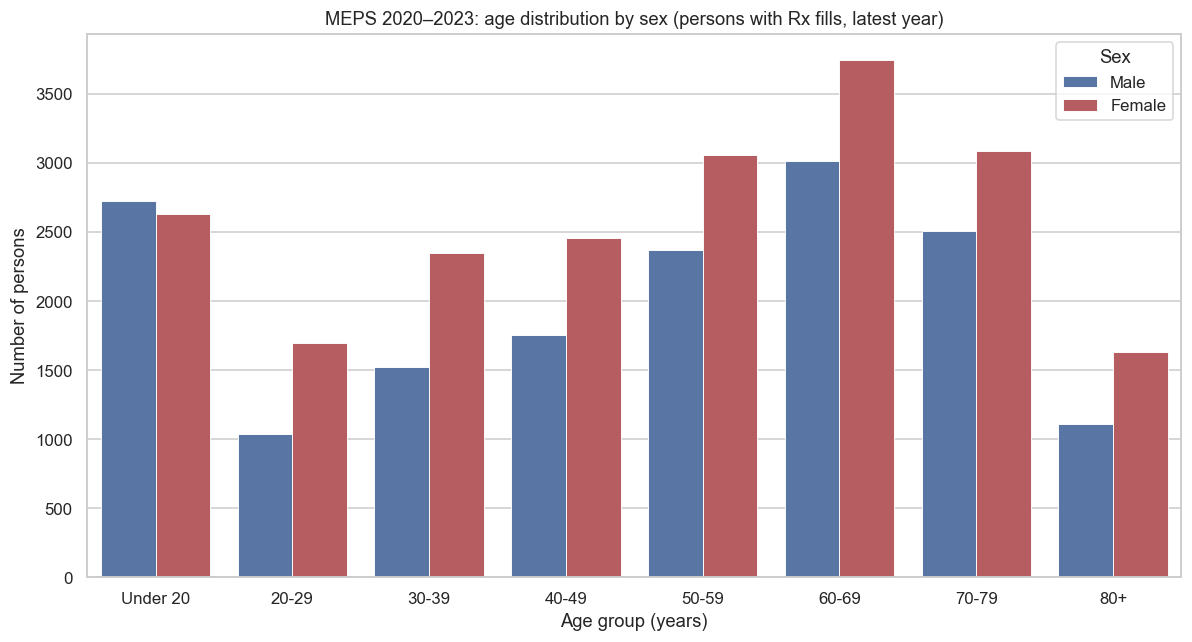

Persons plotted (latest year only): 36,698


Sex,Female,Male,All
age_group,,,
Under 20,2631,2724,5355
20-29,1697,1039,2736
30-39,2347,1524,3871
40-49,2456,1757,4213
50-59,3055,2367,5422
60-69,3748,3016,6764
70-79,3088,2506,5594
80+,1630,1113,2743
All,20652,16046,36698


In [8]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

AGE_BIN_EDGES = [0, 20, 30, 40, 50, 60, 70, 80, 86]
AGE_BIN_LABELS = [
    "Under 20", "20-29", "30-39", "40-49",
    "50-59", "60-69", "70-79", "80+",
]
YEAR_AGE_COL = {2020: "AGE20X", 2021: "AGE21X", 2022: "AGE22X", 2023: "AGE23X"}


def pick_age(df: pd.DataFrame) -> pd.Series:
    out = pd.Series(np.nan, index=df.index, dtype="float64")
    for year, col in YEAR_AGE_COL.items():
        if col not in df.columns:
            continue
        mask = df["meps_year"].eq(year)
        out.loc[mask] = pd.to_numeric(df.loc[mask, col], errors="coerce")
    return out


# One row per person-year, then keep latest year only per DUPERSID
_first_person_year = merged_df.groupby(["DUPERSID", "meps_year"], observed=True).head(1)
person_year_demo = _first_person_year[["DUPERSID", "meps_year", "SEX"]].copy()
person_year_demo["age"] = pick_age(_first_person_year)

person_latest_demo = (
    person_year_demo.sort_values(["DUPERSID", "meps_year"])
    .groupby("DUPERSID", observed=True)
    .tail(1)
    .loc[lambda d: d["age"].between(0, 85)]
    .assign(
        Sex=lambda d: d["SEX"].map({1: "Male", 2: "Female"}),
        age_group=lambda d: pd.cut(
            d["age"],
            bins=AGE_BIN_EDGES,
            labels=AGE_BIN_LABELS,
            right=False,
        ),
    )
    .dropna(subset=["Sex", "age_group"])
)

palette = {"Male": "#4C72B0", "Female": "#C44E52"}

fig, ax = plt.subplots(figsize=(11, 6))
sns.countplot(
    data=person_latest_demo,
    x="age_group",
    hue="Sex",
    order=AGE_BIN_LABELS,
    hue_order=["Male", "Female"],
    palette=palette,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)

ax.set_title("MEPS 2020–2023: age distribution by sex (persons with Rx fills, latest year)")
ax.set_xlabel("Age group (years)")
ax.set_ylabel("Number of persons")
ax.legend(title="Sex", frameon=True, loc="upper right")

plt.tight_layout()
plt.show()

print(f"Persons plotted (latest year only): {len(person_latest_demo):,}")
pd.crosstab(person_latest_demo["age_group"], person_latest_demo["Sex"], margins=True)

### Age distribution by sex (merged 2020–2023)

One bar group per age band; blue = Male, red = Female. Unit = **person-year** (each `DUPERSID` in each `meps_year` they appear), using year-matched age (`AGE20X`–`AGE23X`).

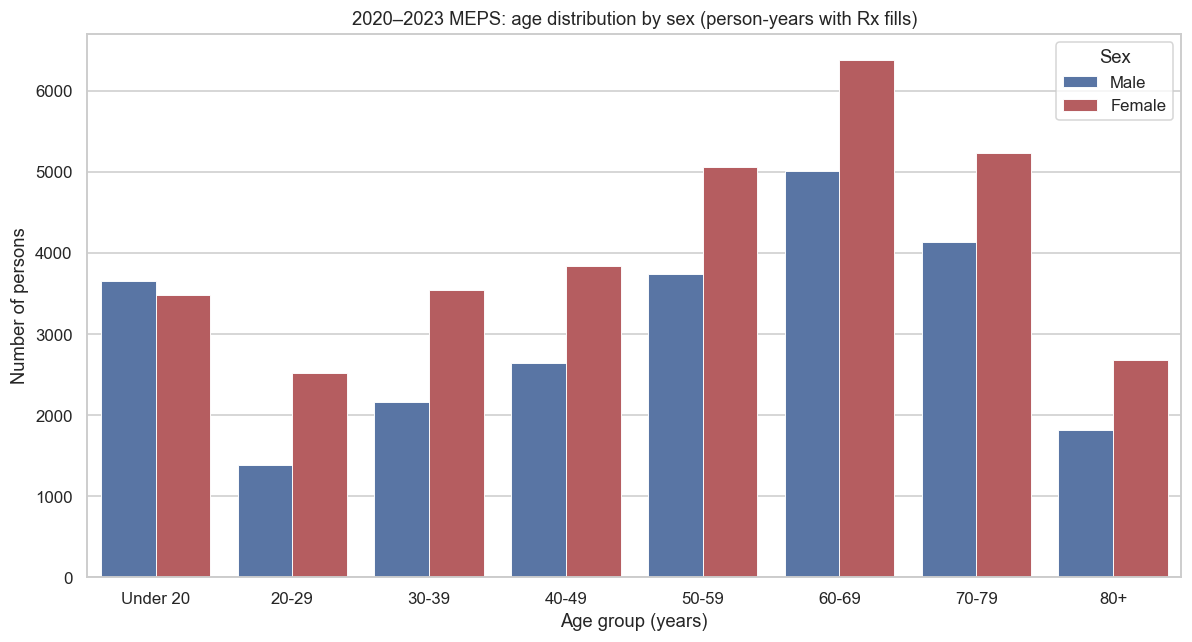

Sex,Female,Male,All
age_group,,,
Under 20,3487,3658,7145
20-29,2515,1387,3902
30-39,3550,2169,5719
40-49,3839,2640,6479
50-59,5056,3743,8799
60-69,6386,5009,11395
70-79,5235,4138,9373
80+,2685,1818,4503
All,32753,24562,57315


In [9]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

AGE_BIN_EDGES = [0, 20, 30, 40, 50, 60, 70, 80, 86]
AGE_BIN_LABELS = [
    "Under 20", "20-29", "30-39", "40-49",
    "50-59", "60-69", "70-79", "80+",
]
AGE_COL_BY_YEAR = {2020: "AGE20X", 2021: "AGE21X", 2022: "AGE22X", 2023: "AGE23X"}


def pick_age_by_year(df: pd.DataFrame) -> pd.Series:
    age = pd.Series(np.nan, index=df.index, dtype="float64")
    for year, col in AGE_COL_BY_YEAR.items():
        if col not in df.columns:
            continue
        mask = df["meps_year"].eq(year)
        age.loc[mask] = pd.to_numeric(df.loc[mask, col], errors="coerce")
    return age


# One row per person per year (same approach as yearly EDA notebooks)
_person_year_idx = merged_df.groupby(["DUPERSID", "meps_year"], observed=True).head(1).index
person_demo = (
    merged_df.loc[_person_year_idx, ["DUPERSID", "meps_year", "SEX"]]
    .assign(age=lambda d: pick_age_by_year(merged_df.loc[_person_year_idx]))
    .loc[lambda d: d["age"].between(0, 85)]
    .assign(
        Sex=lambda d: d["SEX"].map({1: "Male", 2: "Female"}),
        age_group=lambda d: pd.cut(
            d["age"],
            bins=AGE_BIN_EDGES,
            labels=AGE_BIN_LABELS,
            right=False,
        ),
    )
    .dropna(subset=["Sex", "age_group"])
)

palette = {"Male": "#4C72B0", "Female": "#C44E52"}

fig, ax = plt.subplots(figsize=(11, 6))
sns.countplot(
    data=person_demo,
    x="age_group",
    hue="Sex",
    order=AGE_BIN_LABELS,
    hue_order=["Male", "Female"],
    palette=palette,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)

ax.set_title("2020–2023 MEPS: age distribution by sex (person-years with Rx fills)")
ax.set_xlabel("Age group (years)")
ax.set_ylabel("Number of persons")
ax.legend(title="Sex", frameon=True, loc="upper right")

plt.tight_layout()
plt.show()

pd.crosstab(person_demo["age_group"], person_demo["Sex"], margins=True)

In [10]:
merged_df.head()

,meps_year,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,...,RXSTL20,RXWCP20,RXOSR20,RXPTR20,RXOTH20,PERWT20F,FAMWT20F,FAMWT20C,SAQWT20F,DIABW20F
0,2023,2790002101,2790002101002,2790002101002303001,2790002101002303,3,BD PEN NEEDL,-15,8290320550,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,2790002101,2790002101006,2790002101006403001,2790002101006403,4,PREDNISONE,PREDNISONE,591544210,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,2790002101,2790002101007,2790002101007403001,2790002101007403,4,PREDNISONE,PREDNISONE,70954006020,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,2790002101,2790002101008,2790002101008403001,2790002101008403,4,METFORMIN,METFORMIN,70010006305,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,2790002101,2790002101008,2790002101008403002,2790002101008403,4,METFORMIN,METFORMIN,378718505,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Preview in stack order (meps_year is column 0). Avoid .sample() — it randomizes years.
preview_cols = ["meps_year", "DUPERSID", "RXNAME", "SEX"]
merged_df.loc[:, preview_cols].head(20)

,meps_year,DUPERSID,RXNAME,SEX
0,2023,2790002101,BD PEN NEEDL,2
1,2023,2790002101,PREDNISONE,2
2,2023,2790002101,PREDNISONE,2
3,2023,2790002101,METFORMIN,2
4,2023,2790002101,METFORMIN,2
5,2023,2790002101,METFORMIN,2
6,2023,2790002101,METFORMIN,2
7,2023,2790002101,METFORMIN,2
8,2023,2790002101,VITAMIN D,2
9,2023,2790006101,LEVOTHYROXIN,2


### First 5 rows, all columns

First 5 rows of `merged_df` with every column visible (run the merge cells above first).

In [12]:
from IPython.display import display

first_five = merged_df.head(5)

# All 3,906 columns × 5 rows (scroll horizontally in the output).
with pd.option_context(
    "display.max_rows", 5,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", 40,
    "display.expand_frame_repr", False,
):
    display(first_five)

meps_year    DUPERSID        DRUGIDX             RXRECIDX           LINKIDX  PURCHRD        RXNAME    RXDRGNAM        RXNDC  RXQUANTY RXFORM RXSTRENG RXSTRUNT  RXDAYSUP  TC1  TC1S1  TC1S1_1  TC2  TC3  RXSF23X  RXMR23X  RXMD23X  RXPV23X  RXOT23X  RXXP23X     DUID  PID  PANEL  DATAYEAR FAMID31 FAMID42 FAMID53 FAMID23 FAMIDYR CPSFAMID  FCSZ1231  FCRP1231 RULETR31 RULETR42 RULETR53 RULETR23  RUSIZE31  RUSIZE42  RUSIZE53  RUSIZE23  RUCLAS31  RUCLAS42  RUCLAS53  RUCLAS23  FAMSZE31  FAMSZE42  FAMSZE53  FAMSZE23  FMRS1231  FAMS1231  FAMSZEYR  FAMRFPYR  REGION31  REGION42  REGION53  REGION23  REFPRS31  REFPRS42  REFPRS53  REFPRS23  RESP31  RESP42  RESP53  RESP23  PROXY31  PROXY42  PROXY53  PROXY23  INTVLANG  INTVTYPE31  INTVTYPE42  INTVTYPE53  BEGRFM31  BEGRFY31  ENDRFM31  ENDRFY31  BEGRFM42  BEGRFY42  ENDRFM42  ENDRFY42  BEGRFM53  BEGRFY53  ENDRFM53  ENDRFY53  ENDRFM23  ENDRFY23  KEYNESS  INSCOP31  INSCOP42  INSCOP53  INSCOP23  INSC1231  INSCOPE  ELGRND31  ELGRND42  ELGRND53  ELGRND23  PSTATS31  PSTATS42  PSTATS53  RURSLT31  RURSLT42  RURSLT53  AGE31X  AGE42X  AGE53X  AGE23X  AGELAST  DOBMM  DOBYY  SEX  RACEV1X  RACEV2X  RACEAX  RACEBX  RACEWX  RACETHX  HISPANX  HISPNCAT  MARRY31X  MARRY42X  MARRY53X  MARRY23X  SPOUID31  SPOUID42  SPOUID53  SPOUID23  SPOUIN31  SPOUIN42  SPOUIN53  SPOUIN23  EDUCYR  HIDEG  FTSTU31X  FTSTU42X  FTSTU53X  FTSTU23X  ACTDTY31  ACTDTY42  ACTDTY53  EVERSERVED  REFRL31X  REFRL42X  REFRL53X  REFRL23X  OTHLGSPK  WHTLGSPK  HWELLSPK  BORNUSA  YRSINUS  MOPID31X  MOPID42X  MOPID53X  DAPID31X  DAPID42X  DAPID53X  HIBPDX  HIBPAGED  BPMLDX  CHDDX  CHDAGED  ANGIDX  ANGIAGED  MIDX  MIAGED  OHRTDX  OHRTAGED  OHRTTYPE  STRKDX  STRKAGED  EMPHDX  EMPHAGED  CHBRON31  CHOLDX  CHOLAGED  CANCERDX  CABLADDR  CABREAST  CACERVIX  CACOLON  CALUNG  CALYMPH  CAMELANO  CAOTHER  CAPROSTA  CASKINNM  CASKINDK  CAUTERUS  DIABDX_M18  DIABAGED  JTPAIN31_M18  ARTHDX  ARTHTYPE  ARTHAGED  ASTHDX  ASTHAGED  ASSTIL31  ASATAK31  ASTHEP31  ASACUT31  ASMRCN31  ASPREV31  ASDALY31  ASPKFL31  ASEVFL31  ASWNFL31  ADHDADDX  ADHDAGED  COVIDEVER31  COVIDEVER53  LCEVER31  LCEVER53  COVSYMNOW31  COVSYMNOW53  COVREDABIL31  COVREDABIL53  COVID12MO31  COVID12MO53  COVMNTHX31  COVMNTHX53  COVYRDX31  COVYRDX53  RTHLTH31  RTHLTH42  RTHLTH53  MNHLTH31  MNHLTH42  MNHLTH53  IADLHP31  ADLHLP31  AIDHLP31  WLKLIM31  LFTDIF31  STPDIF31  WLKDIF31  MILDIF31  STNDIF31  BENDIF31  RCHDIF31  FNGRDF31  ACTLIM31  WRKLIM31  HSELIM31  SCHLIM31  UNABLE31  SOCLIM31  COGLIM31  DFHEAR42  DFSEE42  DFCOG42  DFWLKC42  DFDRSB42  DFERND42  ANYLMI23  CHPMED42  CHPMHB42  CHPMCN42  CHSERV42  CHSRHB42  CHSRCN42  CHLIMI42  CHLIHB42  CHLICO42  CHTHER42  CHTHHB42  CHTHCO42  CHCOUN42  CHEMPB42  CSHCN42  GETTRB42  MOMPRO42  DADPRO42  UNHAP42  SCHLBH42  HAVFUN42  ADUPRO42  NERVAF42  SIBPRO42  KIDPRO42  SPRPRO42  SCHPRO42  HOMEBH42  CHILCR42  CHILWW42  CHRTCR42  CHRTWW42  CHAPPT42  CHLIST42  CHEXPL42  CHRESP42  CHPRTM42  CHHECR42  CHSPEC42_M18  CHEYRE42_M18  LSTETH53  PHYEXE53  OFTSMK53  COVAXEVR31  COVAXEVR42  COVAXEVR53  COVAXNEW31  COVAXNEW42  COVAXNEW53  SAQELIG  ADPROX42  ADGENH42  ADDAYA42  ADCLIM42  ADACLS42  ADWKLM42  ADEMLS42  ADMWCF42  ADPAIN42  ADPCFL42  ADENGY42  ADPRST42  ADSOCA42  ADNERV42  ADHOPE42  ADREST42  ADSAD42  ADEFRT42  ADWRTH42  K6SUM42  ADINTR42  ADDPRS42  PHQ242  ADINSA42  ADINSB42  ADRISK42  ADOVER42  ADILCR42  ADILWW42  ADRTCR42  ADRTWW42  ADAPPT42  ADHECR42  ADINST42  ADEZUN42  ADTLHW42  ADFFRM42  ADFHLP42  ADEXPL42  ADLIST42  ADRESP42  ADPRTM42  ADSMOK42  ADNSMK42  ADSPCL42  ADSNSP42  VPCS42  VMCS42  VRFLAG42  ADCMPM42  ADCMPY42  ADLANG42  DDNWRK23  OTHDYS23  OTHNDD23  ACCELI42  HAVEUS42  PRACTP42  YNOUSC42_M18  PROVTY42_M18  PLCTYP42  TMTKUS42  TYPEPE42  LOCATN42  HSPLAP42  WHITPR42  BLCKPR42  ASIANP42  NATAMP42  PACISP42  OTHRCP42  PROVSEX42  PHNREG42  OFFHOU42  AFTHOU42  TREATM42  DECIDE42  EXPLOP42  PRVSPK42  DLAYCA42  AFRDCA42  DLAYDN42  AFRDDN42  DLAYPM42  AFRDPM42  EMPST31  EMPST42  EMPST53  RNDFLG31  MORJOB31  MORJOB42  MORJOB53  EVRWRK  HRWG31X  HRWG42X  HRWG53X 

## Target 2: Diagnostic Analysis

**Unit of analysis:** one row per person per year (`DUPERSID` + `meps_year`), among patients with at least one Rx fill in `merged_df`.

**Proxies used (MEPS fill + person files):**

| Concept | Variable / rule |
|---------|-----------------|
| Adherence score | **MPR** = `min(1, sum(RXDAYSUP) / 365)` per person-year |
| Non-adherent flag | MPR &lt; 0.80 |
| Rx out-of-pocket cost | Sum of `RXXP{yy}X` per person-year |
| Total person OOP | `TOTSLF{yy}` (annual self/family out-of-pocket) |
| Refill count | Unique `RXRECIDX` per person-year |
| Chronic burden | Count of diagnosis flags (`*DX* == 1`) → 0 / 1 / 2 / 3+ |
| Side-effect proxy | `CHPMED42 == 1` (changed medicine; MEPS self-report) |

**What this can show:** patterns linking adherence to cost, chronic burden, and the side-effect proxy.

**What this cannot prove:** causation — other factors (access, income, polypharmacy) may explain the patterns.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

PERSON_ID = "DUPERSID"
YEAR_SUFFIX = {2020: "20", 2021: "21", 2022: "22", 2023: "23"}

CHRONIC_DX_COLS = [
    "HIBPDX",
    "CHDDX",
    "ANGIDX",
    "MIDX",
    "STRKDX",
    "EMPHDX",
    "CHOLDX",
    "CANCERDX",
    "DIABDX_M18",
    "ARTHDX",
    "ASTHDX",
    "ADHDADDX",
    "OHRTDX",
    "BPMLDX",
]
SIDE_EFFECT_COL = "CHPMED42"
BURDEN_LABELS = ["0", "1", "2", "3+"]
ADHERENCE_THRESHOLD = 0.80


def pick_by_year(df: pd.DataFrame, stem: str, tail: str = "X") -> pd.Series:
    """Pull year-matched payment columns (e.g. RXXP + 23 + X)."""
    out = pd.Series(np.nan, index=df.index, dtype="float64")
    for year, suffix in YEAR_SUFFIX.items():
        col = f"{stem}{suffix}{tail}" if tail else f"{stem}{suffix}"
        if col not in df.columns:
            continue
        mask = df["meps_year"].eq(year)
        out.loc[mask] = pd.to_numeric(df.loc[mask, col], errors="coerce")
    return out


def count_chronic_conditions(frame: pd.DataFrame) -> pd.Series:
    present = [c for c in CHRONIC_DX_COLS if c in frame.columns]
    if not present:
        return pd.Series(0, index=frame.index, dtype="int64")
    flags = frame[present].apply(pd.to_numeric, errors="coerce").eq(1)
    return flags.sum(axis=1).astype("int64")


# --- Fill-level features (subset of merged_df to keep memory manageable) ---
base_cols = [
    PERSON_ID,
    "meps_year",
    "RXRECIDX",
    "RXDAYSUP",
    "TC1S1",
    SIDE_EFFECT_COL,
    *CHRONIC_DX_COLS,
]
fill_cols = [c for c in base_cols if c in merged_df.columns]
fill_df = merged_df[fill_cols].copy()

fill_df["rx_oop_fill"] = pick_by_year(merged_df, "RXXP")
fill_df["days_supply"] = pd.to_numeric(fill_df["RXDAYSUP"], errors="coerce").fillna(0)
fill_df["n_chronic_fill"] = count_chronic_conditions(fill_df)
fill_df["side_effect_flag"] = (
    pd.to_numeric(fill_df.get(SIDE_EFFECT_COL), errors="coerce").eq(1)
)

# --- Person-year panel ---
person_year = (
    fill_df.groupby([PERSON_ID, "meps_year"], observed=True)
    .agg(
        n_refills=("RXRECIDX", "nunique"),
        total_days_supply=("days_supply", "sum"),
        rx_oop_total=("rx_oop_fill", "sum"),
        n_chronic=("n_chronic_fill", "max"),
        side_effect_flag=("side_effect_flag", "max"),
        med_group_mode=("TC1S1", lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan),
    )
    .reset_index()
)

# Person-level annual OOP (constant within person-year; take first fill row).
_first_fill_idx = merged_df.groupby([PERSON_ID, "meps_year"], observed=True).head(1).index
person_oop = pd.DataFrame({
    PERSON_ID: merged_df.loc[_first_fill_idx, PERSON_ID].values,
    "meps_year": merged_df.loc[_first_fill_idx, "meps_year"].values,
    "tot_oop_person": pick_by_year(merged_df.loc[_first_fill_idx], "TOTSLF", tail="").values,
})
person_year = person_year.merge(person_oop, on=[PERSON_ID, "meps_year"], how="left")

person_year["adherence_mpr"] = (person_year["total_days_supply"] / 365).clip(upper=1)
person_year["non_adherent"] = person_year["adherence_mpr"] < ADHERENCE_THRESHOLD
person_year["chronic_burden"] = pd.cut(
    person_year["n_chronic"],
    bins=[-0.1, 0.9, 1.9, 2.9, 100],
    labels=BURDEN_LABELS,
)

print(f"Person-year rows: {len(person_year):,}")
print(person_year.groupby("meps_year", observed=True).size())
person_year.head()

Person-year rows: 57,737
meps_year
2020    15743
2021    16534
2022    13602
2023    11858
dtype: int64


,DUPERSID,meps_year,n_refills,total_days_supply,rx_oop_total,n_chronic,side_effect_flag,med_group_mode,tot_oop_person,adherence_mpr,non_adherent,chronic_burden
0,2320005101,2020,3,270,26.85,0,False,99,41.0,0.739726,True,0
1,2320005101,2021,6,360,130.89,0,False,99,48.0,0.986301,False,0
2,2320005102,2020,9,810,564.34,4,False,19,50.0,1.000000,False,3+
3,2320012102,2020,18,52,302.21,5,False,99,322.0,0.142466,True,3+
4,2320012102,2021,31,-150,688.22,5,False,99,1524.0,-0.410959,True,3+


In [14]:
# Aggregated diagnostic table: meps_year × chronic burden
diagnostic_agg = (
    person_year.groupby(["meps_year", "chronic_burden"], observed=True)
    .agg(
        n_patients=(PERSON_ID, "count"),
        avg_adherence=("adherence_mpr", "mean"),
        pct_non_adherent=("non_adherent", lambda s: 100 * s.mean()),
        avg_rx_oop=("rx_oop_total", "mean"),
        avg_person_oop=("tot_oop_person", "mean"),
        avg_refills=("n_refills", "mean"),
        pct_side_effect_proxy=("side_effect_flag", lambda s: 100 * s.mean()),
    )
    .round(3)
    .reset_index()
)

diagnostic_agg

,meps_year,chronic_burden,n_patients,avg_adherence,pct_non_adherent,avg_rx_oop,avg_person_oop,avg_refills,pct_side_effect_proxy
0,2020,0,3667,0.225,85.220,931.761,793.683,5.759,5.372
1,2020,1,2961,0.345,72.273,1665.823,922.189,9.942,11.651
2,2020,2,2103,0.499,55.159,1881.342,1109.308,14.369,2.901
3,2020,3+,7012,0.665,32.045,4273.710,1447.228,28.378,0.043
4,2021,0,3819,0.233,83.975,979.038,1049.208,6.020,5.027
5,2021,1,2975,0.385,68.504,2825.484,1113.916,10.417,10.454
6,2021,2,2242,0.508,53.434,2076.412,1269.952,14.663,2.364
7,2021,3+,7498,0.650,32.102,4960.873,1562.380,28.879,0.040
8,2022,0,3281,0.230,84.913,860.060,1025.282,5.637,4.358
9,2022,1,2489,0.381,69.787,2539.089,1392.850,9.677,10.004


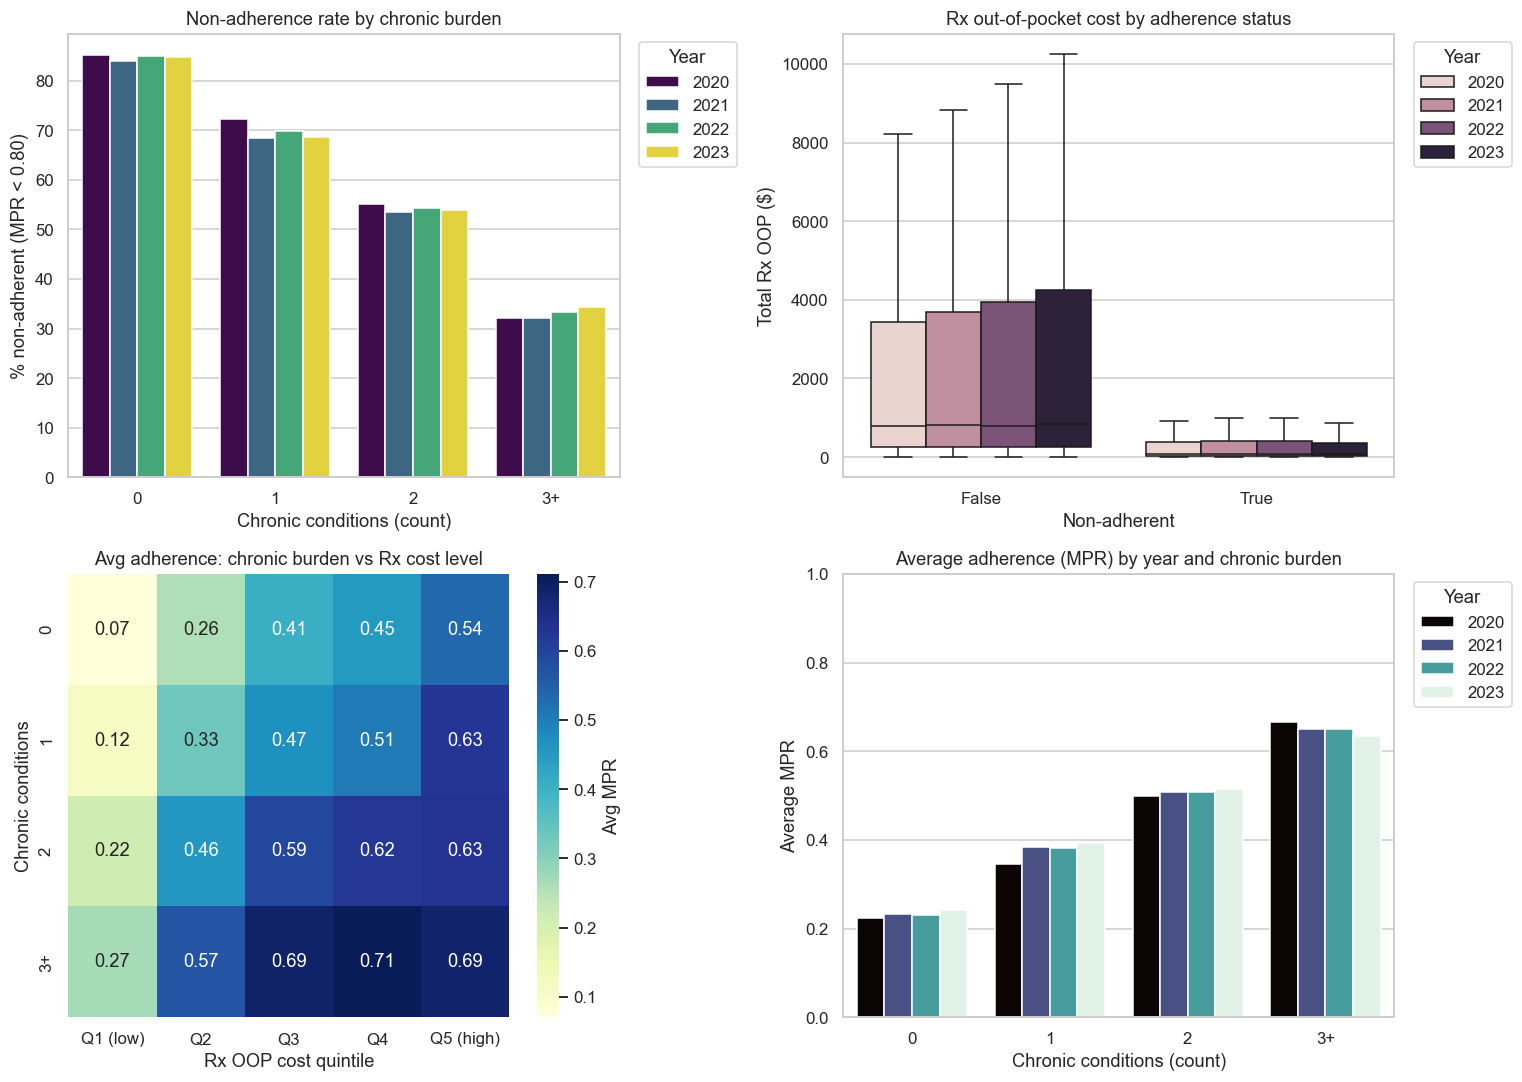

Side-effect proxy breakdown:


,n_patients,avg_adherence,pct_non_adherent,avg_rx_oop
side_effect_label,,,,
Changed med (proxy),2026,0.341,72.655,2734.328
No proxy flag,55711,0.486,54.237,3084.711


In [15]:
from IPython.display import display

# --- Visualizations ---
plot_df = person_year.dropna(subset=["chronic_burden"]).copy()
plot_df["chronic_burden"] = pd.Categorical(plot_df["chronic_burden"], categories=BURDEN_LABELS, ordered=True)
plot_df["cost_level"] = pd.qcut(
    plot_df["rx_oop_total"].fillna(0),
    q=5,
    labels=["Q1 (low)", "Q2", "Q3", "Q4", "Q5 (high)"],
    duplicates="drop",
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Non-adherence rate by chronic burden (grouped by year)
sns.barplot(
    data=diagnostic_agg,
    x="chronic_burden",
    y="pct_non_adherent",
    hue="meps_year",
    palette="viridis",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Non-adherence rate by chronic burden")
axes[0, 0].set_xlabel("Chronic conditions (count)")
axes[0, 0].set_ylabel("% non-adherent (MPR < 0.80)")
axes[0, 0].legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")

# 2) Cost distribution by adherence status
sns.boxplot(
    data=plot_df,
    x="non_adherent",
    y="rx_oop_total",
    hue="meps_year",
    showfliers=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Rx out-of-pocket cost by adherence status")
axes[0, 1].set_xlabel("Non-adherent")
axes[0, 1].set_ylabel("Total Rx OOP ($)")
axes[0, 1].legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")

# 3) Heatmap: chronic burden × cost level → average adherence
heat = (
    plot_df.groupby(["chronic_burden", "cost_level"], observed=True)["adherence_mpr"]
    .mean()
    .unstack("cost_level")
)
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1, 0], cbar_kws={"label": "Avg MPR"})
axes[1, 0].set_title("Avg adherence: chronic burden vs Rx cost level")
axes[1, 0].set_xlabel("Rx OOP cost quintile")
axes[1, 0].set_ylabel("Chronic conditions")

# 4) Grouped bar: avg adherence by year and chronic burden
sns.barplot(
    data=diagnostic_agg,
    x="chronic_burden",
    y="avg_adherence",
    hue="meps_year",
    palette="mako",
    ax=axes[1, 1],
)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title("Average adherence (MPR) by year and chronic burden")
axes[1, 1].set_xlabel("Chronic conditions (count)")
axes[1, 1].set_ylabel("Average MPR")
axes[1, 1].legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# Side-effect proxy vs adherence (diagnostic for Q3)
side_tbl = (
    plot_df.assign(side_effect_label=np.where(plot_df["side_effect_flag"], "Changed med (proxy)", "No proxy flag"))
    .groupby("side_effect_label", observed=True)
    .agg(
        n_patients=(PERSON_ID, "count"),
        avg_adherence=("adherence_mpr", "mean"),
        pct_non_adherent=("non_adherent", lambda s: 100 * s.mean()),
        avg_rx_oop=("rx_oop_total", "mean"),
    )
    .round(3)
)
print("Side-effect proxy breakdown:")
display(side_tbl)

In [16]:
# complete df merge — same pipeline as each year’s EDA notebook:
# merged_df → events (LINKIDX/EVNTIDX) → conditions (CONDIDX), then stack 2023→2020.
# Run the setup + merged_df cells above first.

import pandas as pd
from pathlib import Path

_required = ["merged_df", "MEPS_DIR", "EXCEL_ENGINE", "YEAR_CONFIGS"]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise NameError(
        f"Run the setup and merged_df cells above first. Missing: {', '.join(_missing)}"
    )

COMPLETE_DF_FILES = {
    2023: {"events_file": "h248if1.xlsx", "conditions_file": "h249.xlsx"},
    2022: {"events_file": "h239if1.xlsx", "conditions_file": "h241.xlsx"},
    2021: {"events_file": "h229if1.xlsx", "conditions_file": "h231.xlsx"},
    2020: {"events_file": "h220if1.xlsx", "conditions_file": "h222.xlsx"},
}


def resolve_merge_suffixes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in list(df.columns):
        if col.endswith("_y"):
            df.drop(columns=[col], inplace=True)
        elif col.endswith("_x"):
            df.rename(columns={col: col[:-2]}, inplace=True)
    return df


def build_complete_df(cfg: dict, meps_dir: Path, year_merged_df: pd.DataFrame) -> pd.DataFrame:
    files = COMPLETE_DF_FILES[cfg["meps_year"]]

    df_medical_conditions = pd.read_excel(
        meps_dir / files["events_file"],
        engine=EXCEL_ENGINE,
    )
    merge_on_linkidx = pd.merge(
        year_merged_df,
        df_medical_conditions,
        how="inner",
        left_on="LINKIDX",
        right_on="EVNTIDX",
    )
    merge_on_linkidx = resolve_merge_suffixes(merge_on_linkidx)

    df2 = pd.read_excel(
        meps_dir / files["conditions_file"],
        engine=EXCEL_ENGINE,
    )
    complete_df = pd.merge(
        merge_on_linkidx,
        df2,
        how="inner",
        on="CONDIDX",
    )
    complete_df = resolve_merge_suffixes(complete_df)

    complete_df = complete_df.assign(meps_year=cfg["meps_year"])
    other = [c for c in complete_df.columns if c != "meps_year"]
    return complete_df[["meps_year"] + other]


complete_year_frames: list[pd.DataFrame] = []

for cfg in YEAR_CONFIGS:
    year_merged = merged_df.loc[merged_df["meps_year"] == cfg["meps_year"]].copy()
    year_complete = build_complete_df(cfg, MEPS_DIR, year_merged)
    files = COMPLETE_DF_FILES[cfg["meps_year"]]
    print(
        f"{cfg['meps_year']}: complete_df {year_complete.shape} "
        f"(events {files['events_file']} + conditions {files['conditions_file']})"
    )
    complete_year_frames.append(year_complete)

complete_df_2023 = complete_year_frames[0]
complete_df_2022 = complete_year_frames[1]
complete_df_2021 = complete_year_frames[2]
complete_df_2020 = complete_year_frames[3]

complete_df = pd.concat(complete_year_frames, axis=0, ignore_index=True, sort=False)
other_cols = [c for c in complete_df.columns if c != "meps_year"]
complete_df = complete_df[["meps_year"] + other_cols]

_year_blocks = complete_df["meps_year"].drop_duplicates().tolist()
assert _year_blocks == [2023, 2022, 2021, 2020], f"Unexpected row order: {_year_blocks}"

print(f"\ncomplete_df shape: {complete_df.shape}")
print("Rows by meps_year (stack order preserved):")
print(complete_df["meps_year"].value_counts().sort_index(ascending=False))
print(
    f"First row year: {complete_df['meps_year'].iloc[0]}  |  "
    f"Last row year: {complete_df['meps_year'].iloc[-1]}"
)

2023: complete_df (196482, 3931) (events h248if1.xlsx + conditions h249.xlsx)
2022: complete_df (239827, 3935) (events h239if1.xlsx + conditions h241.xlsx)
2021: complete_df (314242, 3934) (events h229if1.xlsx + conditions h231.xlsx)
2020: complete_df (291987, 3932) (events h220if1.xlsx + conditions h222.xlsx)

complete_df shape: (1042538, 3941)
Rows by meps_year (stack order preserved):
meps_year
2023    196482
2022    239827
2021    314242
2020    291987
Name: count, dtype: int64
First row year: 2023  |  Last row year: 2020


In [17]:
complete_df.head()

,meps_year,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,...,CRND6,CRND7,CRND8,CRND9,HHNUM,IPNUM,OPNUM,OBNUM,ERNUM,RXNUM
0,2023,2790002101,2790002101002,2790002101002303001,2790002101002303,3,BD PEN NEEDL,-15,8290320550,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,2790002101,2790002101007,2790002101007403001,2790002101007403,4,PREDNISONE,PREDNISONE,70954006020,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023,2790002101,2790002101008,2790002101008403001,2790002101008403,4,METFORMIN,METFORMIN,70010006305,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,2790002101,2790002101008,2790002101008403002,2790002101008403,4,METFORMIN,METFORMIN,378718505,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023,2790002101,2790002101008,2790002101008503001,2790002101008503,5,METFORMIN,METFORMIN,68645058259,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
